In [1]:
# Import Libraries.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Full_Titanic.csv")
df = df.drop(columns='Unnamed: 0')
df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Group,family_size,family_type,surname,Title_Grouped,ticket_type
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,Adults,2,Double,Braund,Mr,Prefix


### Knowing about the dataset
**Columns in the Dataset:-**
- **Survival:-** Whether a passenger survived or not(0/1)
- **Pclass:-** The Socio-Economic Class
            - Upper: 1
            - Middle: 2
            - Lower: 3
- **Sex:-** Gender of the passenger (Male or Female)
- **Age:-** Age in Years
- **SibSp:-** Number of Siblings / Number of Spouses aboard the Titanic.
- **Parch:-** Number of Parents / Children aboard the Titanic.
- **Ticket:-** Ticket number
- **Fare:-** Passenger Fare
- **Cabin:-** Cabin Number
- **Embarked:-** Port of Embarkation
                - C: Cherbourg
                - Q: Queenstown
                - S: Southamptom
- **Age_Group:-** - i) 0-2   --> Infants
                  -ii) 3-12  --> Children
                 -iii) 13-19 --> Teens
                 - iv) 20-30 --> Adults
                 -  v) 31-60 --> Elder Adults
                 - vi) 61+   --> Senior Citizens
- **Family_Size:-** Total members of a family on board.
- **Family_Type:-** 
                    - i) 1   --> Alone
                   - ii) 2   --> Double 
                  - iii) 3-5 --> Small 
                   - iv) > 5 --> Large 
- **Surname:-**
- **Title:-** Mr,Ms,Miss,..etc
- **Ticket_type:-**

In [56]:
# Get more details about data.

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,family_size
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,1309.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479,1.883881
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668,1.583639
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000,1.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800,1.000000
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000,2.000000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200,11.000000


In [4]:
# Looking for information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    1309 non-null   int64  
 1   Survived       891 non-null    float64
 2   Pclass         1309 non-null   int64  
 3   Name           1309 non-null   object 
 4   Sex            1309 non-null   object 
 5   Age            1046 non-null   float64
 6   SibSp          1309 non-null   int64  
 7   Parch          1309 non-null   int64  
 8   Ticket         1309 non-null   object 
 9   Fare           1308 non-null   float64
 10  Cabin          295 non-null    object 
 11  Embarked       1307 non-null   object 
 12  Age_Group      1046 non-null   object 
 13  family_size    1309 non-null   int64  
 14  family_type    1309 non-null   object 
 15  surname        1309 non-null   object 
 16  Title_Grouped  1309 non-null   object 
 17  ticket_type    1309 non-null   object 
dtypes: float

In [66]:
# Total null values.

df.isnull().sum()

PassengerId         0
Survived          418
Pclass              0
Name                0
Sex                 0
Age               263
SibSp               0
Parch               0
Ticket              0
Fare                1
Cabin            1014
Embarked            2
Age_Group         263
family_size         0
family_type         0
surname             0
Title_Grouped       0
ticket_type         0
dtype: int64

In [5]:
# Looking for missing data

df.isnull().mean()*100

PassengerId       0.000000
Survived         31.932773
Pclass            0.000000
Name              0.000000
Sex               0.000000
Age              20.091673
SibSp             0.000000
Parch             0.000000
Ticket            0.000000
Fare              0.076394
Cabin            77.463713
Embarked          0.152788
Age_Group        20.091673
family_size       0.000000
family_type       0.000000
surname           0.000000
Title_Grouped     0.000000
ticket_type       0.000000
dtype: float64

### Observation:- 

- We Observed that there is a missing values in columns:
        - Age:- 20%
        - Cabin:- 77%
        - Embarked:- 0.15%
        - Age_GRoup:- 20.09%

In [6]:
# Convert both attributes columns to Category datatype.

attributes = ["Sex","Embarked"]

def convert_cat(df,attrs):
    for col in attrs:
        df[col] = df[col].astype("category")
convert_cat(df,attributes)

In [7]:
# Checking for null values.

def count_na(df,col):
    print(f"Null Values in {col}: ",df[col].isna().sum())

count_na(df,"Age")
count_na(df,"Cabin")
count_na(df,"Embarked")

Null Values in Age:  263
Null Values in Cabin:  1014
Null Values in Embarked:  2


# Univariate Analysis.
- We use Histogram and a Pie chart will be two useful plots to analyse the **Survived**,**Sex**,**Pclass**,**Age**,**Fare** column as it is a categorical feature. Usesfullness in the sense, both the plots will allow us to observe the distribution of each category in the feature.

In [8]:
# Setting some styles.

sns.set_style("darkgrid")
sns.set_palette("viridis")

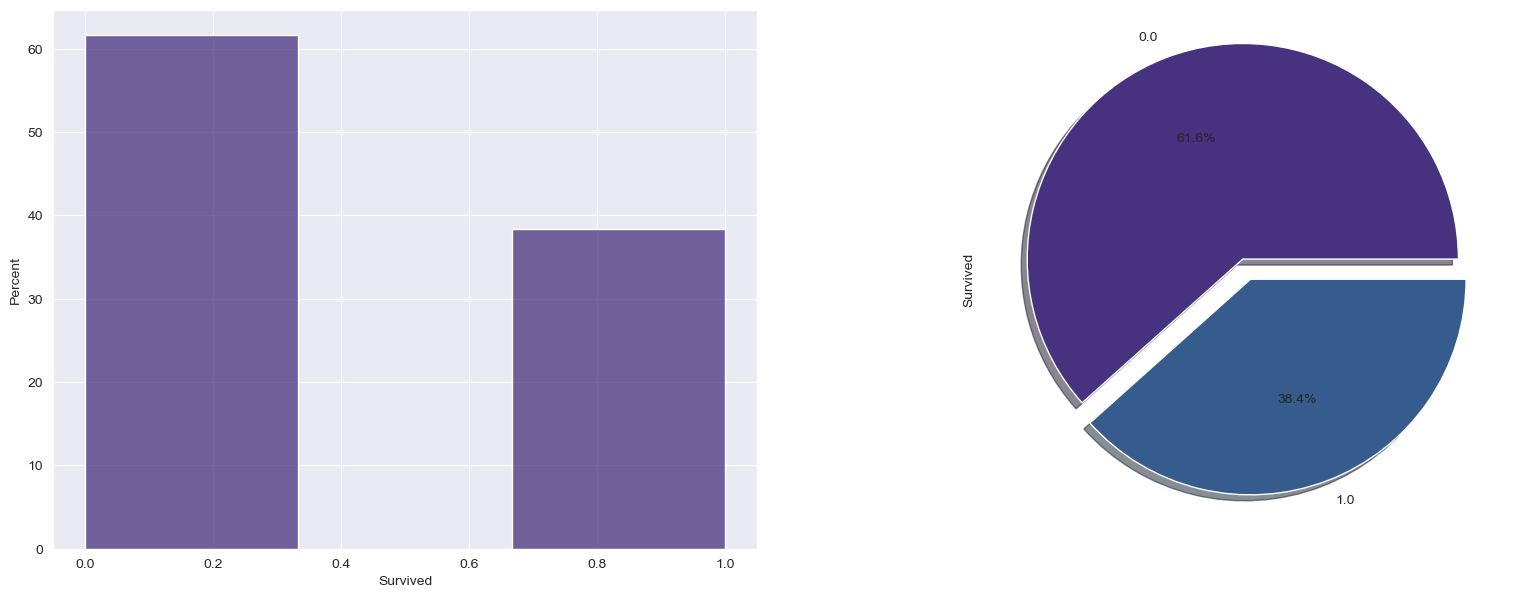

In [9]:
# Analysis of Total Survived.

fig,ax = plt.subplots(1,2,figsize = (20,7))

sns.histplot(data = df, x = 'Survived', stat="percent", bins=3, multiple='stack',ax=ax[0])

df['Survived'].value_counts().plot.pie(explode=[0.1,0],autopct="%1.1f%%",shadow=True, ax=ax[1])

plt.show()

**We Observed from the above plots**
- Only 38.4% of passengers survived the disaster.
- While 61.6% of Passengers didn't Survived!

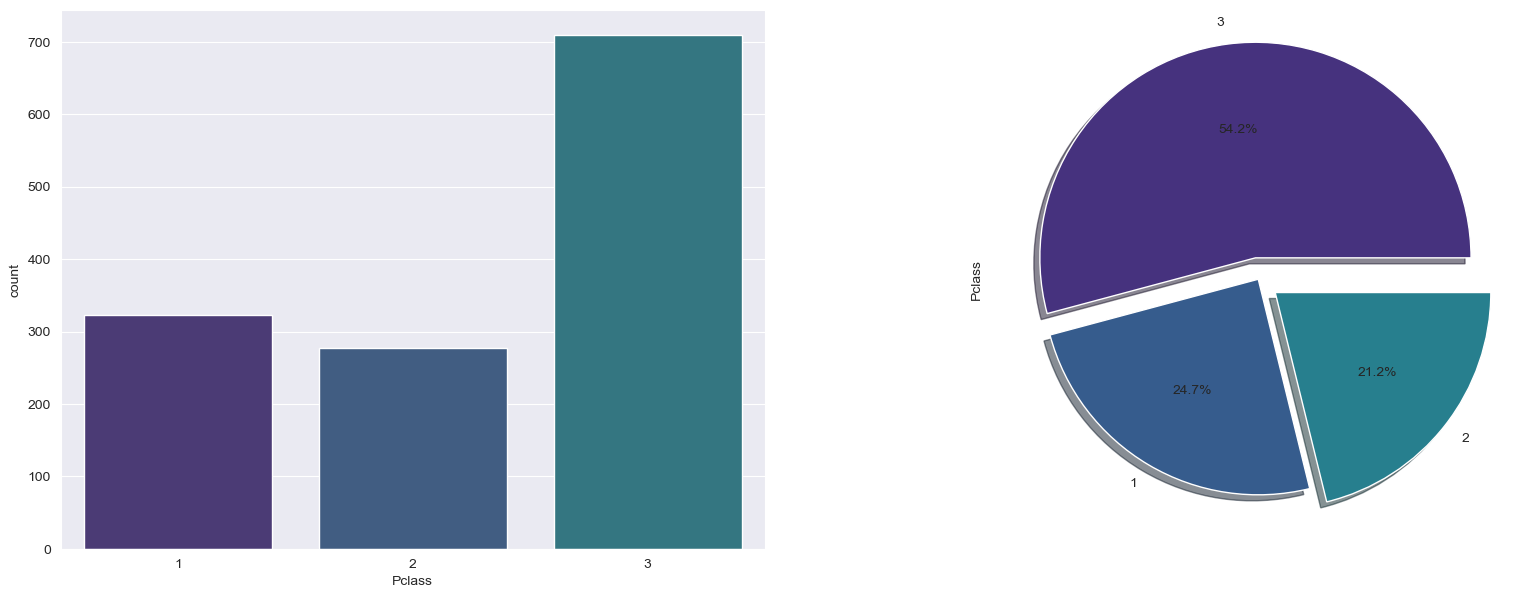

In [10]:
# Anaysis on Pclass


fig , ax = plt.subplots(1,2,figsize=(20,7))

sns.countplot(data=df,x='Pclass',ax=ax[0])
df['Pclass'].value_counts().plot.pie(shadow=True,autopct="%1.1f%%",ax=ax[1],explode=[0.1,0,0.1])

plt.show()


**We observed in the above plot:**
- There are 54.2% passengers who were in 3rd class.
- There are 21.2% passengers who were in 2nd class.
- There are 24.7% passengers who were in 1st class.

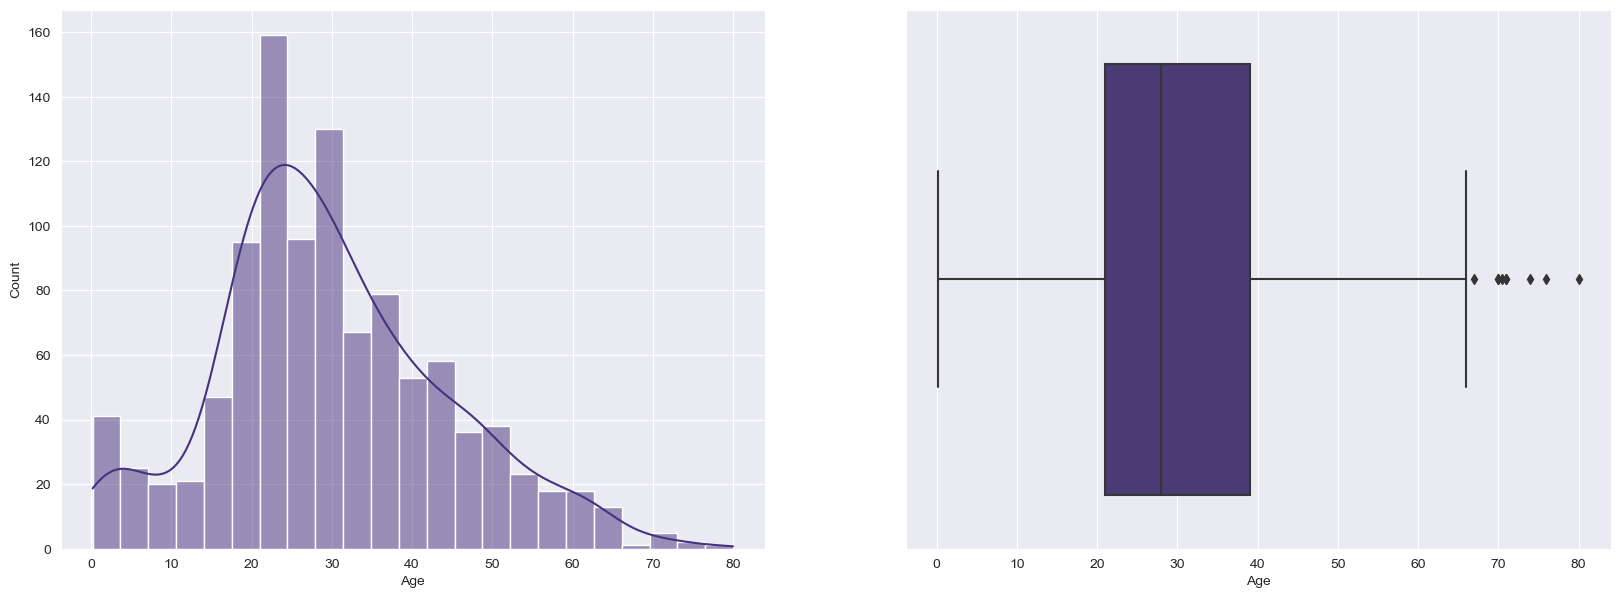

In [11]:
# Analysis of Age

fig,ax = plt.subplots(1,2,figsize = (20,7))
sns.histplot(data=df,x="Age",ax=ax[0],kde=True)
sns.boxplot(data=df,x="Age",ax=ax[1])

plt.show()

**We observed in the above plot:**
- The passengers between the age 15 to 45 are more on the Titanic.
- There are several outliers present in the Age column.

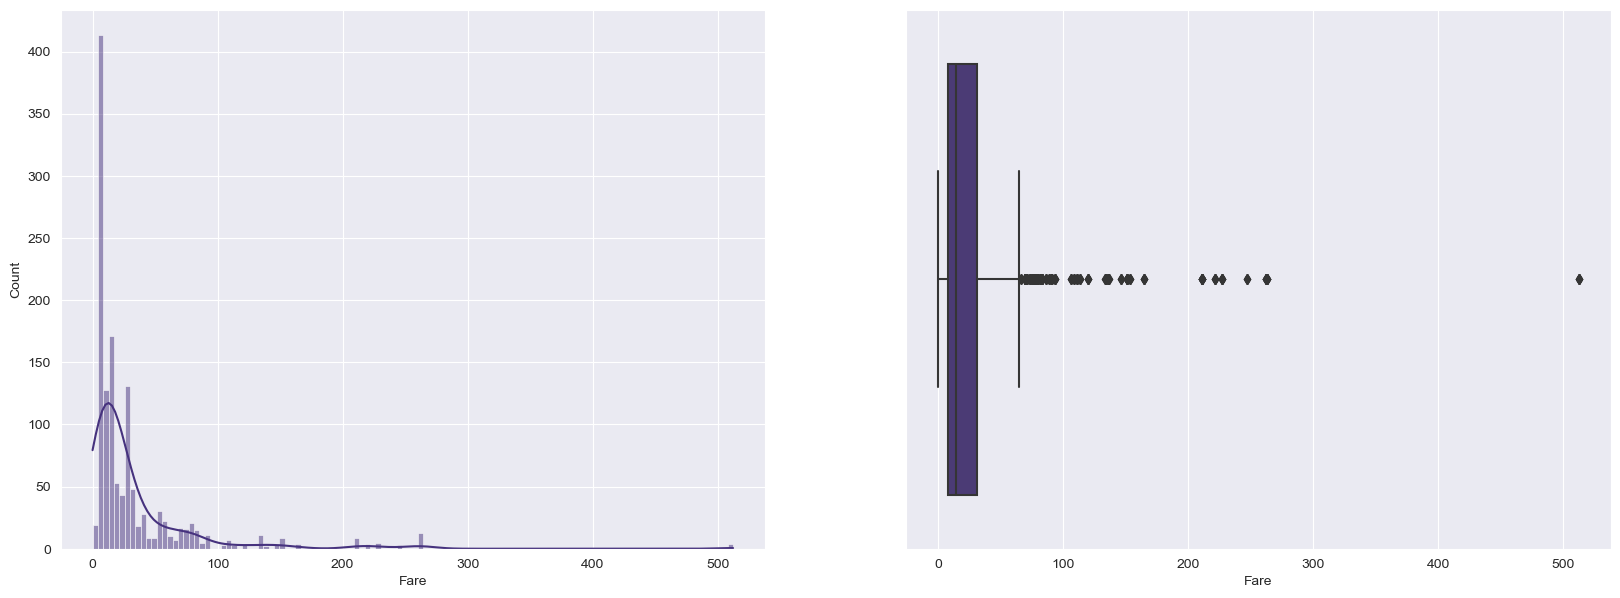

In [12]:
# Analysis on Fare


fig,ax = plt.subplots(1,2,figsize=(20,7))
sns.histplot(data=df,x='Fare',ax=ax[0],kde=True)
sns.boxplot(data=df,x='Fare',ax=ax[1])

plt.show()

**What we observed in above plots:**
- The histogram for *Fare* is quite skewed. Let is observe some facts about *Fare*.

In [13]:
max_fare , min_fare = df["Fare"].max(),df['Fare'].min()

print(f"Number of Passengers who paid {min_fare}:- ",df[df["Fare"]==min_fare].shape[0])
print(f"Number of Passengers who paid {max_fare:.2f}:- ",df[df["Fare"]==max_fare].shape[0])
print(f"Fare given by maximum number of passengers :- ",list(dict(df["Fare"].value_counts()).keys())[0])

Number of Passengers who paid 0.0:-  17
Number of Passengers who paid 512.33:-  4
Fare given by maximum number of passengers :-  8.05


**Observation:-**
- Only 4 passengers paid 512 dollars to be on Titanic.
- 17 Passengers paid no Fare to be on Titanic.
- Maximum passengers paid approximately 8 dollars.

In [14]:
# People who didn't paid a single dollar to be on Titanic.

print(f"Total Passengers: {len(df[df['Fare']==min_fare])}")
df[df['Fare']==min_fare]

Total Passengers: 17


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Group,family_size,family_type,surname,Title_Grouped,ticket_type
179,180,0.0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S,Elder Adults,1,Alone,Leonard,Mr,Prefix
263,264,0.0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S,Elder Adults,1,Alone,Harrison,Mr,Numeric
271,272,1.0,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S,Adults,1,Alone,Tornquist,Mr,Prefix
277,278,0.0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0,NaN,S,NaN,1,Alone,Parkes,Mr,Numeric
302,303,0.0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S,Teens,1,Alone,Johnson,Mr,Prefix
413,414,0.0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0,NaN,S,NaN,1,Alone,Cunningham,Mr,Numeric
466,467,0.0,2,"Campbell, Mr. William",male,NaN,0,0,239853,0.0,NaN,S,NaN,1,Alone,Campbell,Mr,Numeric
481,482,0.0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0,NaN,S,NaN,1,Alone,Frost,Mr,Numeric
597,598,0.0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S,Elder Adults,1,Alone,Johnson,Mr,Prefix
633,634,0.0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0,NaN,S,NaN,1,Alone,Parr,Mr,Numeric


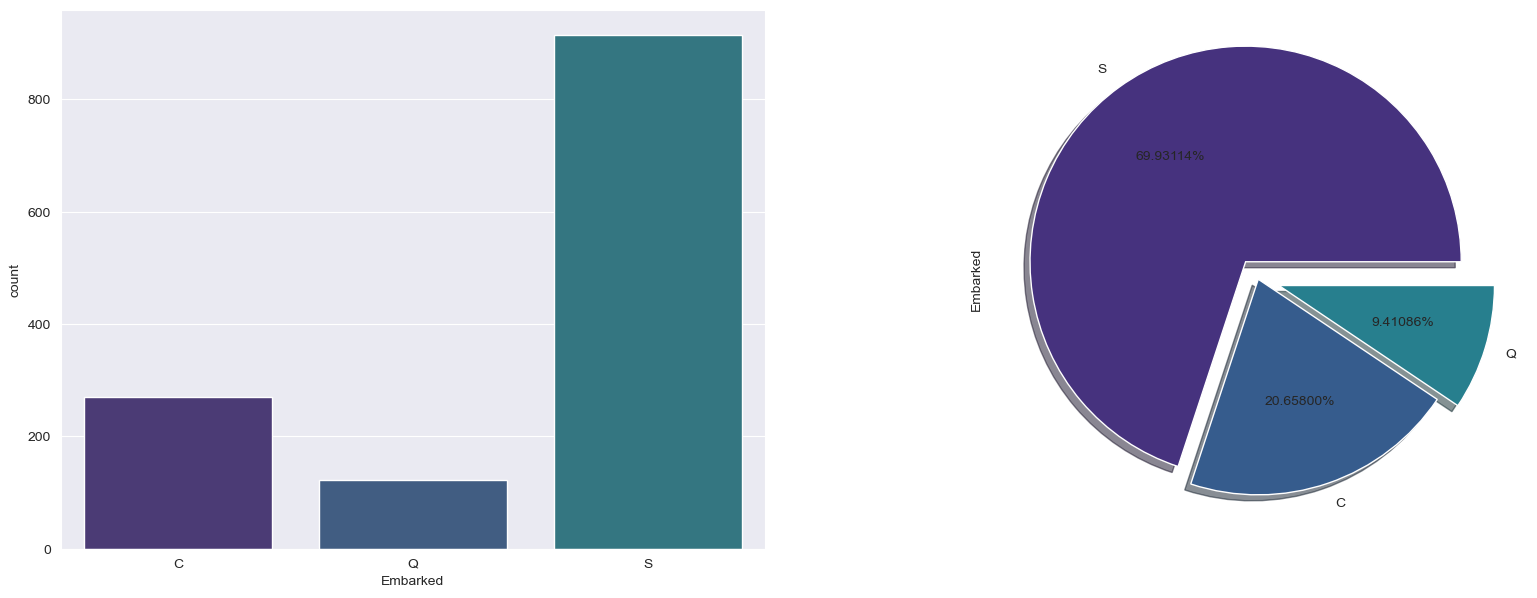

In [15]:
# Analysis on Embarked.

fig,ax = plt.subplots(1,2,figsize=(20,7))
sns.countplot(data=df,x="Embarked",ax=ax[0])
df['Embarked'].value_counts().plot.pie(ax=ax[1],autopct="%1.5f%%",explode=[0.1,0,0.1],shadow=True)

plt.show()

**Observation we saw in above chart:-**
- More than 800 Passengers get from the Southampton city on the Titanic make a total of 69.9% of total Passengers.
- Then comes Cherbourg 20.7% Almost 250 Passengers.
- Atlast comes Queenstown 9.4% i.e. approx 150 Passengers.

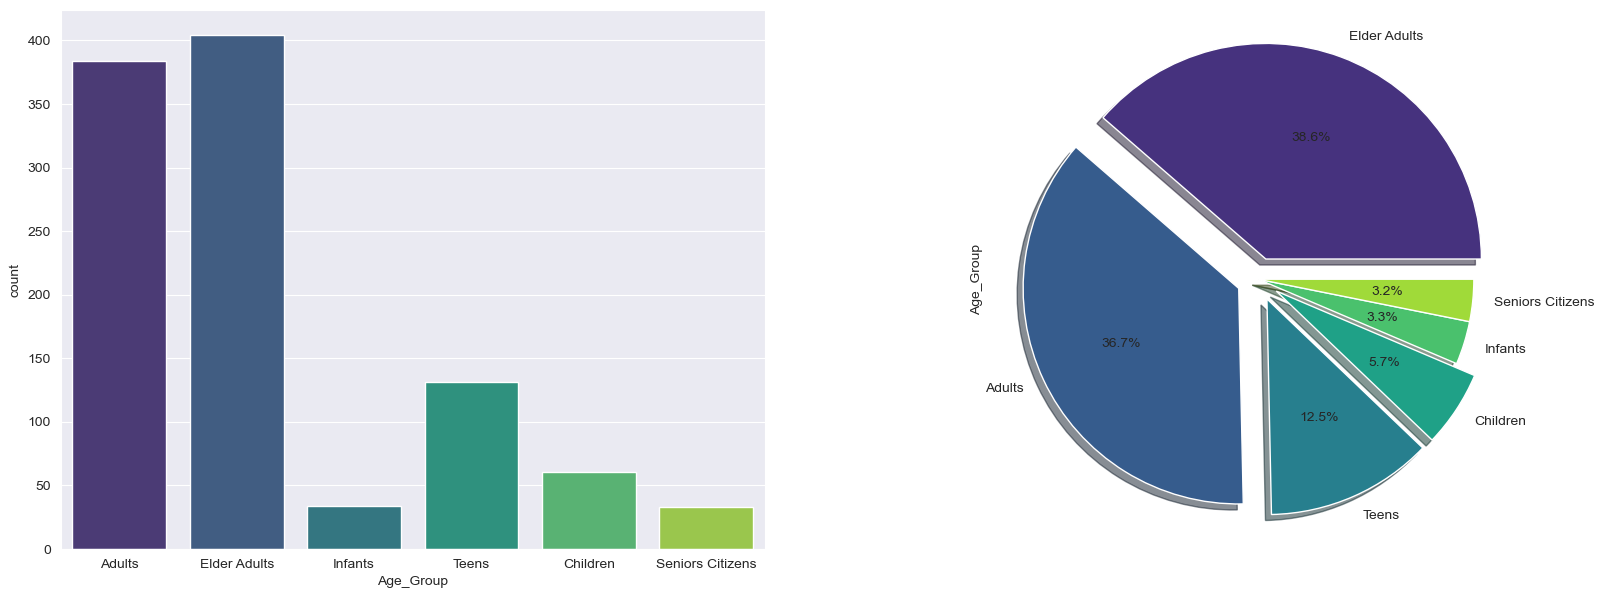

In [16]:
# Analysis on Age_Group.

fig,ax = plt.subplots(1,2,figsize=(20,7))
sns.countplot(data=df,x="Age_Group",ax=ax[0])
df['Age_Group'].value_counts().plot.pie(ax=ax[1],explode=[0.1,0.1,0.1,0.1,0,0],autopct="%1.1f%%",shadow=True)

plt.show()

**Observation From Above Chart:-**
- 31-60 --> Elder Adults - 404 (38.6%)
- 20-30 --> Adults - 384 (36.7%)
- 13-19 --> Teens - 131 (12.5%)
- 3-12 --> Children - 60 (5.7%)
- < 2   -> Infants -34 (3.3%)
- 61+   --> Senior Citizens - 33 (3.2%)

0    891
1    319
2     42
4     22
3     20
8      9
5      6
Name: SibSp, dtype: int64


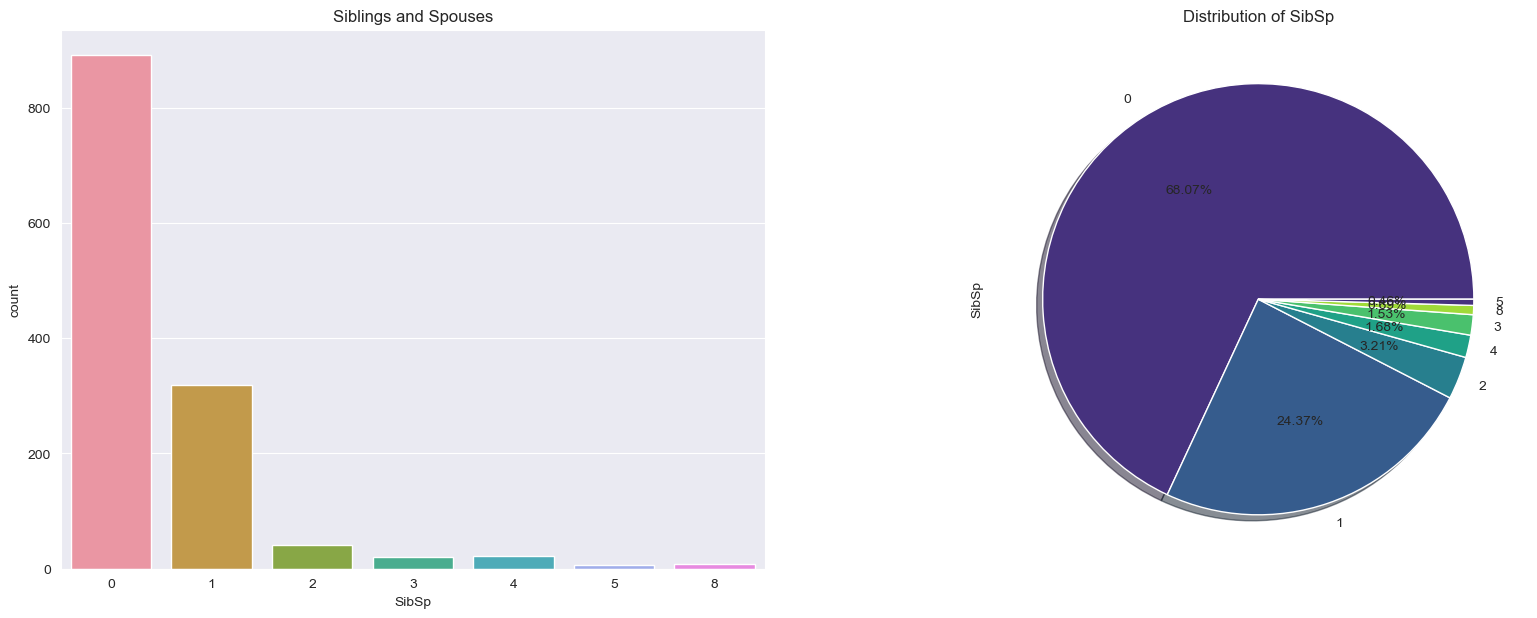

In [17]:
# Analysis on  SibSp.

fig,ax = plt.subplots(1,2,figsize=(20,7))

# SibSp:- 
sns.countplot(data=df,x='SibSp',ax=ax[0]).set_title("Siblings and Spouses")
df['SibSp'].value_counts().plot.pie(ax=ax[1],shadow=True,title='Distribution of SibSp',autopct="%1.2f%%")
x = df['SibSp'].value_counts()
print(x)
plt.show()

**Observation:**
- Around **68.07%** passengers were without SibSp's.
- Around **23.46%** passengers were with SibSp's.
- Approximately **7 to 8%** passengers were with SibSp's.

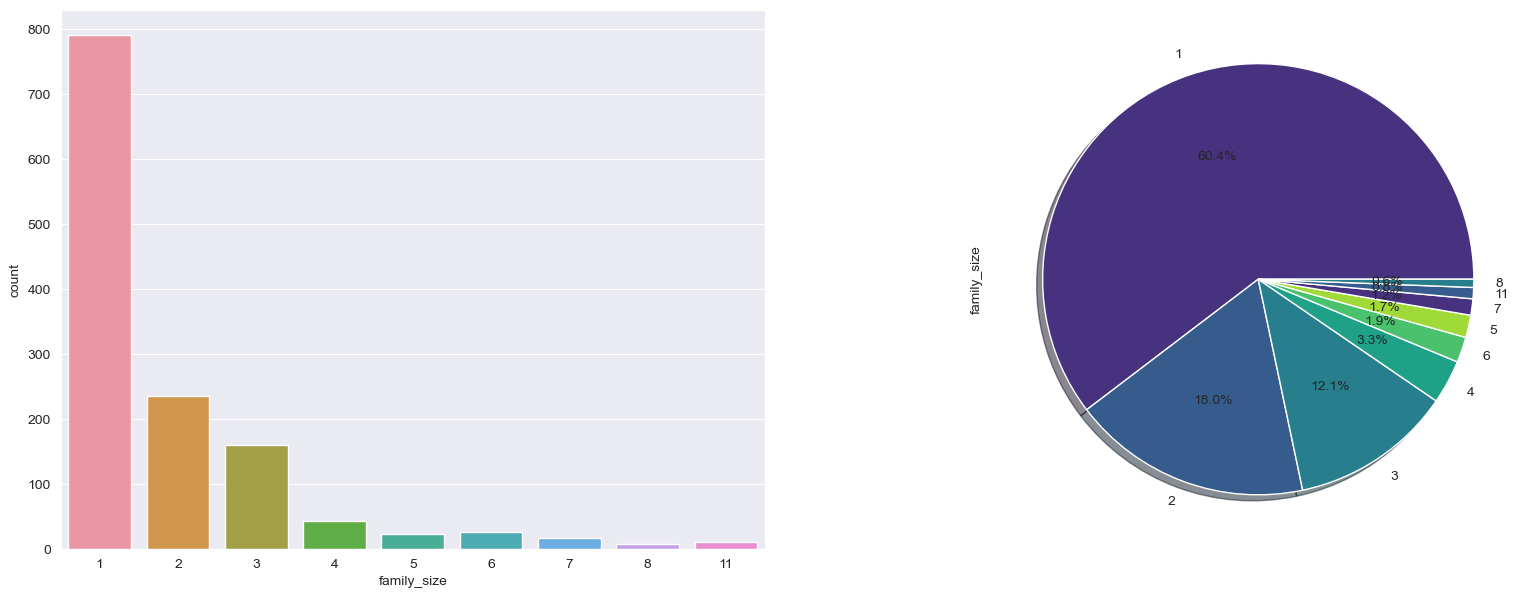

In [18]:
# Analysis on Family Size.

fig,ax = plt.subplots(1,2,figsize=(20,7))
sns.countplot(data=df,x="family_size",ax=ax[0])
df['family_size'].value_counts().plot.pie(ax=ax[1],autopct="%1.1f%%",shadow=True)

plt.show()

**Observations From above Graphs:-**
- A Single passengers are holding a total of 60.4% (790) of space on Titanic.
- Passengers having someone with them holds 18% (235) of space.
- Passengers having a small family or 3 members holds 12.1% (159) of space.
- Passengers with 4 family members holds 3.3% (43) of space.
- Passengers with 5 to 11 familly members holds approx 4 to 5% of total space on the ship.

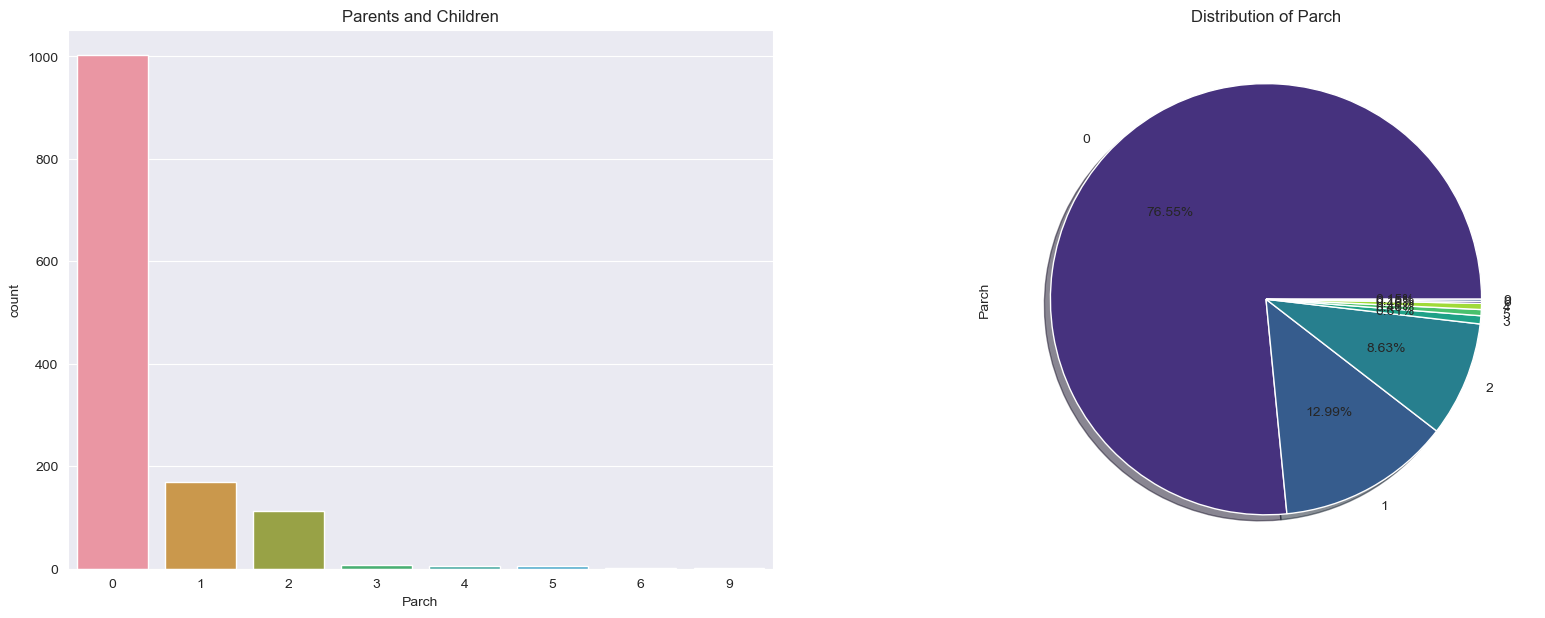

In [19]:
# Analysis on Parch

fig,ax = plt.subplots(1,2,figsize=(20,7))
sns.countplot(data=df,x="Parch",ax=ax[0]).set_title("Parents and Children")
df['Parch'].value_counts().plot.pie(ax=ax[1],shadow=True,title='Distribution of Parch',autopct="%1.2f%%")

plt.show()

**Observation:**
- Around **76.55%** passengers were without Parents and Children.
- Around **13%** passengers were with 1 Parents and Children.
- Around **8.63%** Were with 2 Parch.

Alone     790
Double    235
Small     202
Large      82
Name: family_type, dtype: int64


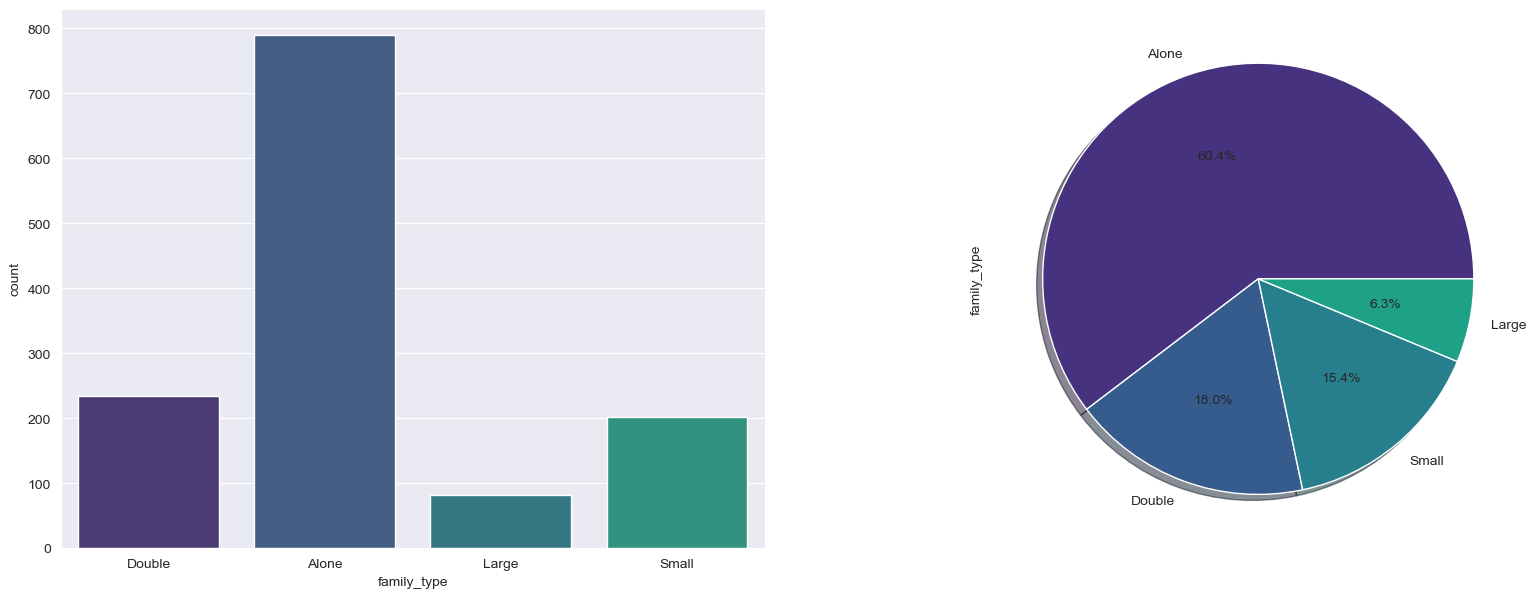

In [20]:
# Analysis on Family Type.

fig,ax = plt.subplots(1,2,figsize=(20,7))
sns.countplot(data=df,x="family_type",ax=ax[0])
df['family_type'].value_counts().plot.pie(ax=ax[1],autopct="%1.1f%%",shadow=True)

x = df['family_type'].value_counts()
print(x)
plt.show()

**Observations on Above Chart:-**
- Passengers travelling Alone was total 790 which holds 60.4% of total space on the ship.
- Passengers having someone with them has total 235 which holds 18% of total space on the ship.
- Passengers having a small family less than 5 members holds 15.4% of the total space on the ship.
- Passengers having more than 5 family members were 82 which holds 6.3% of total space on the ship.

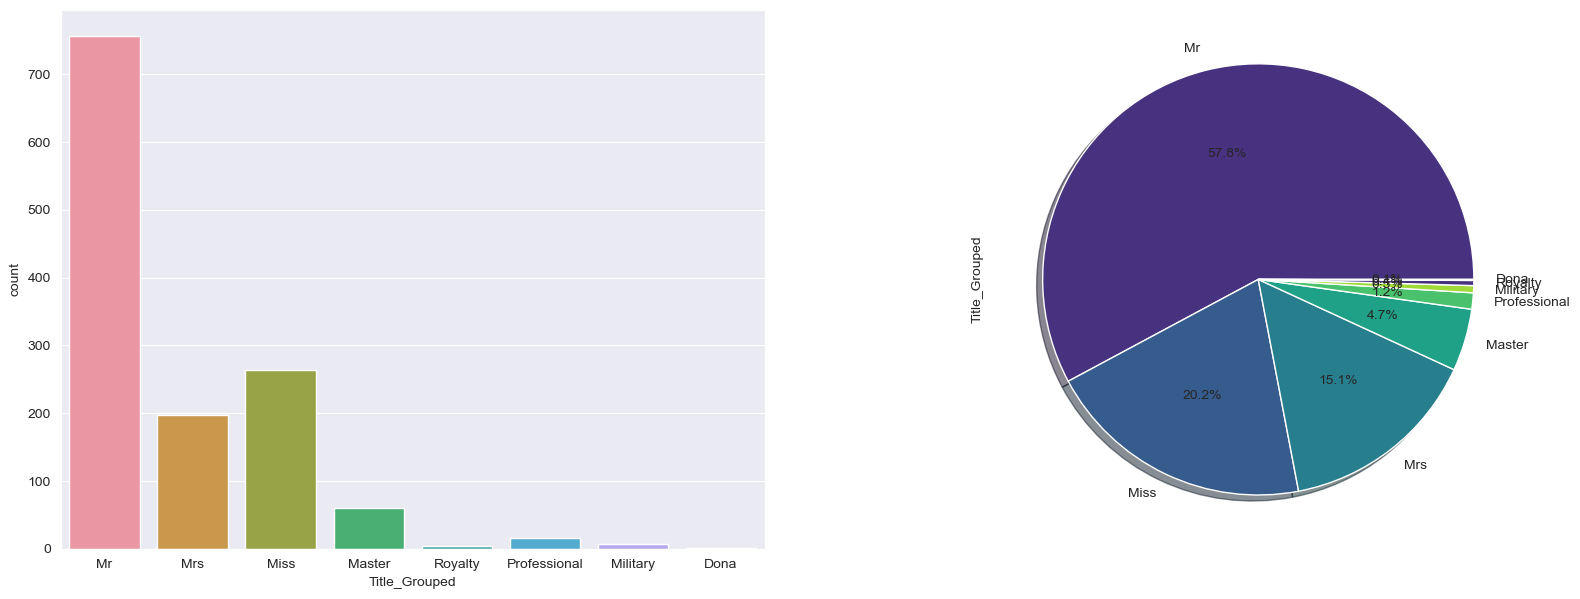

In [21]:
# Analysis on Title Group.

fig,ax = plt.subplots(1,2,figsize=(20,7))
sns.countplot(data=df,x="Title_Grouped",ax=ax[0])
df['Title_Grouped'].value_counts().plot.pie(ax=ax[1],autopct="%1.1f%%",shadow=True)

plt.show()

**Observation from above chart:-**
- Total Males were 757 which holds 57.8%
- Total Unmarried Females were 264 holds 20.2%
- Total Married Females were 198 holds 15.1%
- Total Master Were 61 holds 4.7%
- Total Professional were 16 holds 1.2%
- Total Military Officials were 7 holds 1.2%
- Total Royalty were 5 holds 0.3 %
- There was single Dona.

# ------------------- Bivariate Analysis ------------------

- **CAT vs CAT**

Pclass            1          2          3
Survived                                 
0.0        8.978676  10.886644  41.750842
1.0       15.263749   9.764310  13.355780


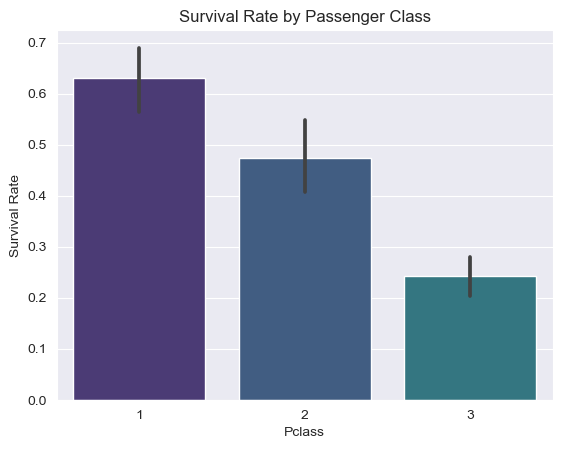

In [22]:
# Survival by Pclass.

ct = pd.crosstab(df['Survived'],df['Pclass'],normalize=True)*100
print(ct)

sns.barplot(data=df, x='Pclass', y='Survived')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

### Observation:-

- We Observed that the ratio of 1st class Passengers were more than 60%.
- For 2nd class its more than 45%
- For 3rd class its less than 30%

Survived        0.0        1.0
Sex                           
female    25.796178  74.203822
male      81.109185  18.890815


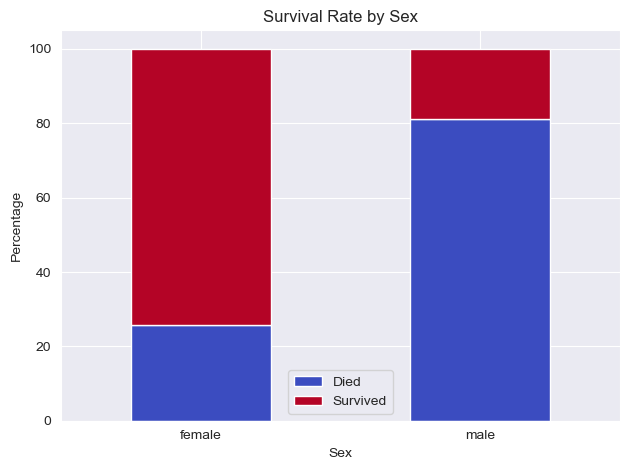

In [23]:
# Survival by Gender

ct = pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100
print(ct)
ct.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title('Survival Rate by Sex')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(['Died', 'Survived'])
plt.tight_layout()
plt.show()

### Observation:- 

- More number of males are deceased in that incident and females were saved.

In [24]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age_Group',
       'family_size', 'family_type', 'surname', 'Title_Grouped',
       'ticket_type'],
      dtype='object')

Embarked
S    33.695652
Q    38.961039
C    55.357143
Name: Survived, dtype: float64
-----------------------------------
Age_Group
Seniors Citizens    22.727273
Adults              35.510204
Teens               41.052632
Elder Adults        42.049470
Children            55.555556
Infants             62.500000
Name: Survived, dtype: float64
-----------------------------------
family_type
Large     16.129032
Alone     30.353818
Double    55.279503
Small     61.068702
Name: Survived, dtype: float64
-----------------------------------
Title_Grouped
Mr              15.667311
Professional    23.076923
Military        40.000000
Master          57.500000
Royalty         60.000000
Miss            70.270270
Mrs             79.365079
Dona                  NaN
Name: Survived, dtype: float64
-----------------------------------


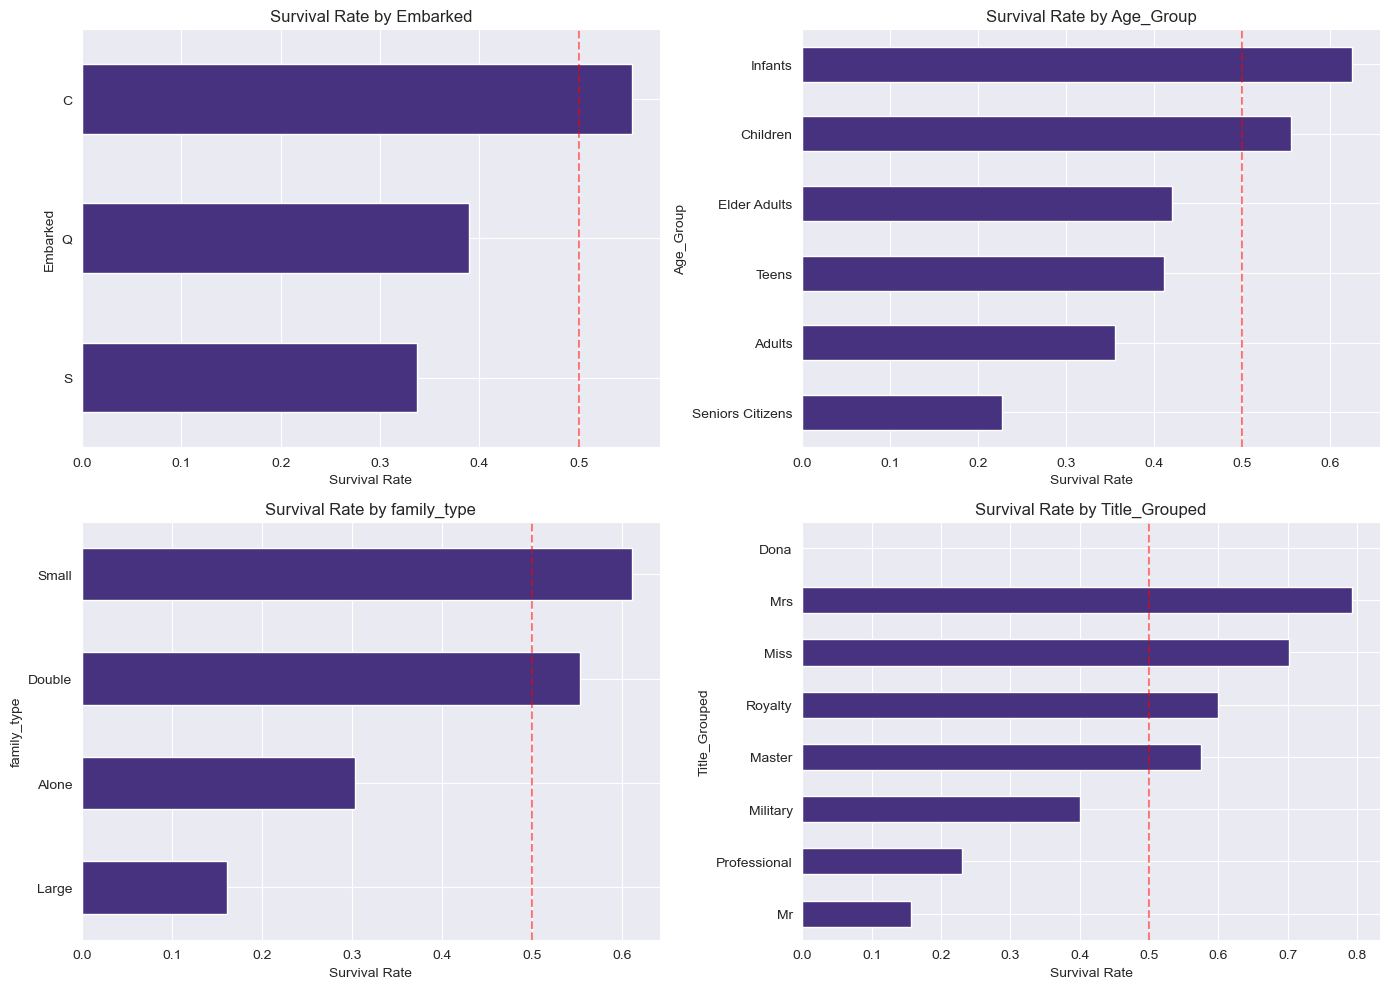

In [25]:
cats = ['Embarked', 'Age_Group', 'family_type', 'Title_Grouped']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), cats):
    rates = df.groupby(col)['Survived'].mean().sort_values()
    rates.plot(kind='barh', ax=ax)
    print(rates*100)
    print("-"*35)
    ax.set_title(f'Survival Rate by {col}')
    ax.set_xlabel('Survival Rate')
    ax.axvline(0.5, linestyle='--', color='red', alpha=0.5)
plt.tight_layout()
plt.show()

Sex        female       male
Pclass                      
1       96.808511  36.885246
2       92.105263  15.740741
3       50.000000  13.544669


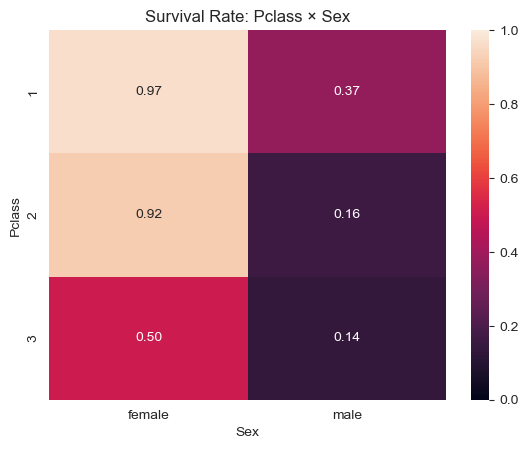

In [26]:
pivot = df.pivot_table(values='Survived', index='Pclass', columns='Sex', aggfunc='mean')
print(pivot*100)
sns.heatmap(pivot, annot=True, fmt='.2f', vmin=0, vmax=1)
plt.title('Survival Rate: Pclass × Sex')
plt.show()

### Observation:- 
- In 1st Class Females were 97% saved and males 37%.
- In 2nd Class Females were 92% Saved and Males 15.7%.
- In 3rd Class Females were 50% saved and Males 13%

### CAT vs NUM

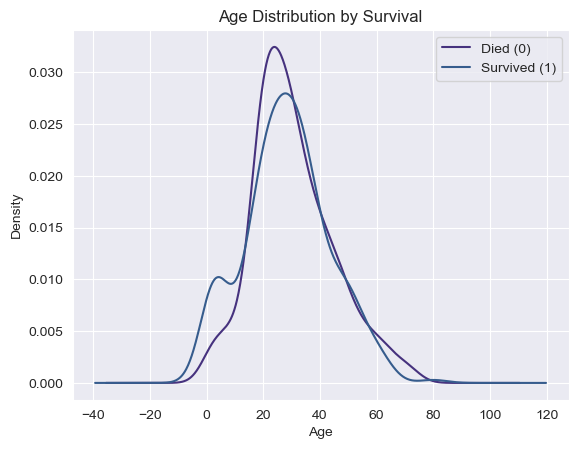

In [27]:
# Survival by Age.

df.groupby('Survived')['Age'].plot(kind='kde', legend=True)
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.legend(['Died (0)', 'Survived (1)'])
plt.show()

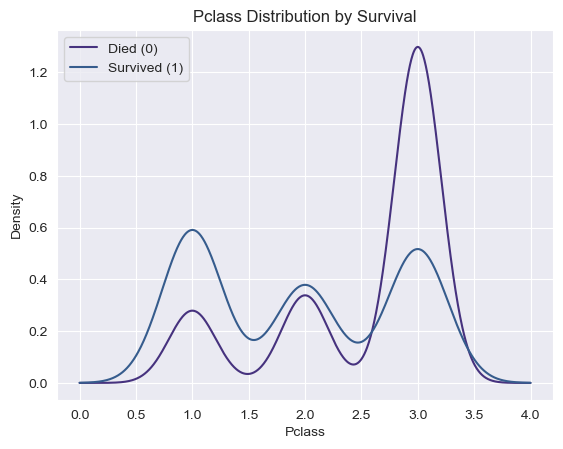

In [28]:
# Survival by Pclass

df.groupby('Survived')['Pclass'].plot(kind='kde', legend=True)
plt.title('Pclass Distribution by Survival')
plt.xlabel('Pclass')
plt.legend(['Died (0)', 'Survived (1)'])
plt.show()

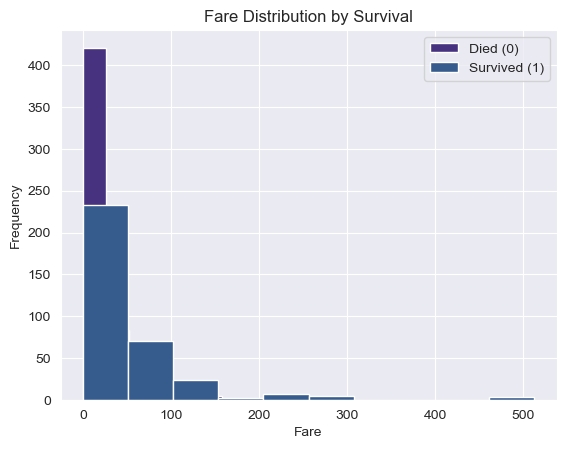

In [29]:
# Survived by Fare

df.groupby('Survived')['Fare'].plot(kind='hist', legend=True)
plt.title('Fare Distribution by Survival')
plt.xlabel('Fare')
plt.legend(['Died (0)', 'Survived (1)'])
plt.show()

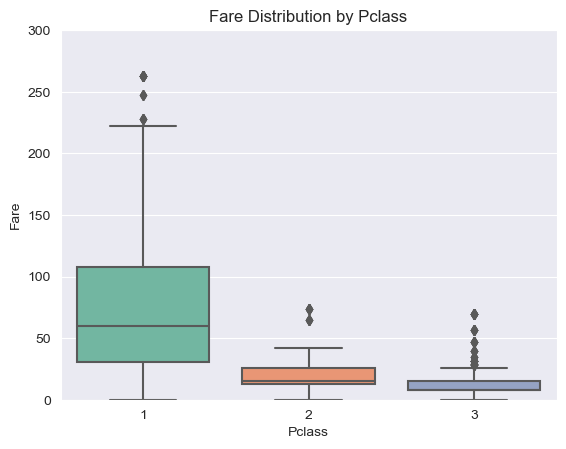

In [30]:
sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set2')
plt.title('Fare Distribution by Pclass')
plt.ylim(0, 300)  # cap outliers
plt.show()

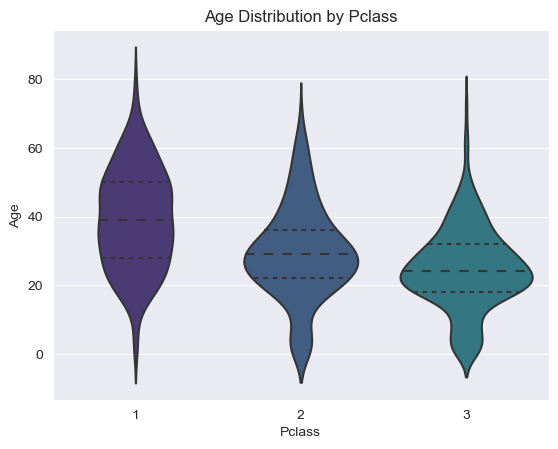

In [31]:
# Age and Pclass

sns.violinplot(data=df, x='Pclass', y='Age', inner='quartile')
plt.title('Age Distribution by Pclass')
plt.show()

### Observation:- 

- We observed that in 1st Class the average passengers were saved was of age 40,
- In 2nd class it was around 35.
- In 3rd class it was approx 23-25.

Sex
female    46.198097
male      26.154601
Name: Fare, dtype: float64


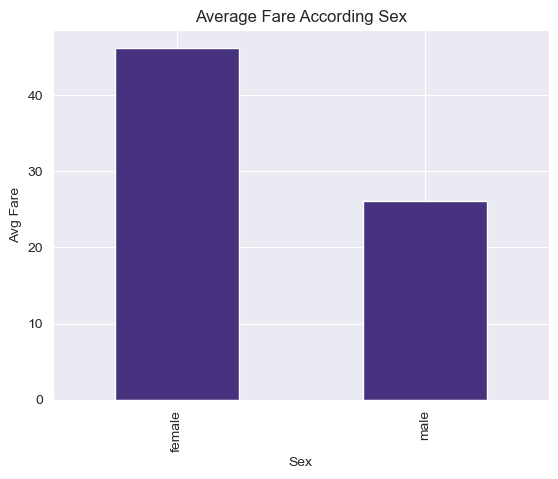

In [32]:
# Average fare of the gender.
av_fare = df.groupby("Sex")['Fare'].mean()
av_fare.plot(kind='bar')
plt.title("Average Fare According Sex")
plt.ylabel("Avg Fare")
print(av_fare)

### Observation:- 

- We can see the average fare for womens was also high(46.19) comparing to males(26.15)

Sex
female    65.116279
male      52.500000
Name: Survived, dtype: float64


<AxesSubplot:xlabel='Sex'>

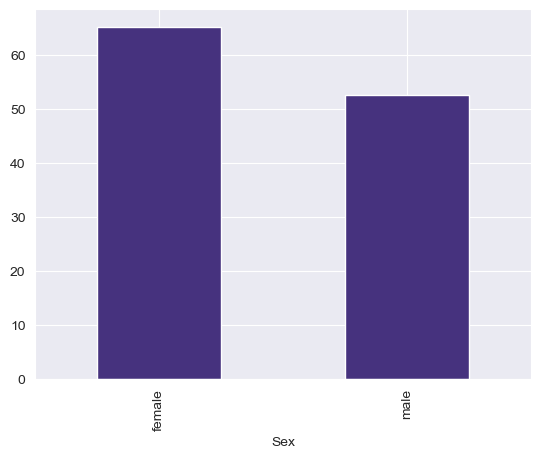

In [33]:
# Children survived in this accident.

children = df[df['Age']<16]
child_grp = children.groupby("Sex")['Survived'].mean()*100
print(child_grp)
child_grp.plot(kind='bar')

### Observations:- 

- We can see that in Children the Female Children were saved the most around(65.11%) and the Male children were saved the least(52.50%).

### NUM vs NUM

In [34]:
df.groupby('SibSp').agg(
    Total_Passengers = ('Survived', 'count'),
    Total_Survived   = ('Survived', 'sum'),
    Survival_Pct     = ('Survived', lambda x: round(x.mean()*100, 1))
).sort_values(by= "Survival_Pct",ascending=False)

,Total_Passengers,Total_Survived,Survival_Pct
SibSp,,,
1,209,112.0,53.6
2,28,13.0,46.4
0,608,210.0,34.5
3,16,4.0,25.0
4,18,3.0,16.7
5,5,0.0,0.0
8,7,0.0,0.0


Text(0.5, 1.0, 'Survival Rate For SibSp')

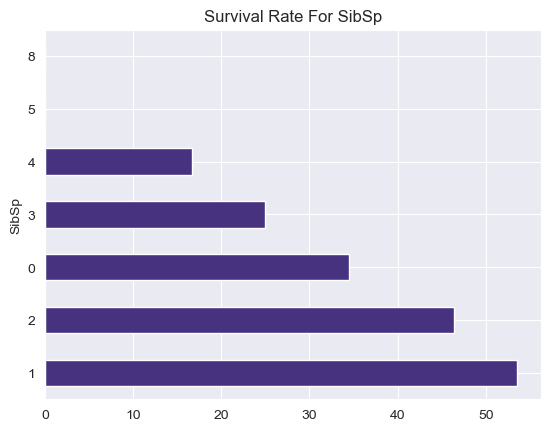

In [35]:
# Survival Rate for Siblings and spouses.

grp = df.groupby("SibSp")['Survived'].mean().sort_values(ascending = False)*100
grp.plot(kind='barh')
plt.title("Survival Rate For SibSp")

### Observation:-
- According to the data we can clearly see the passengers those who have someone with them have the more possibility of the survival comparing to the family or large group.

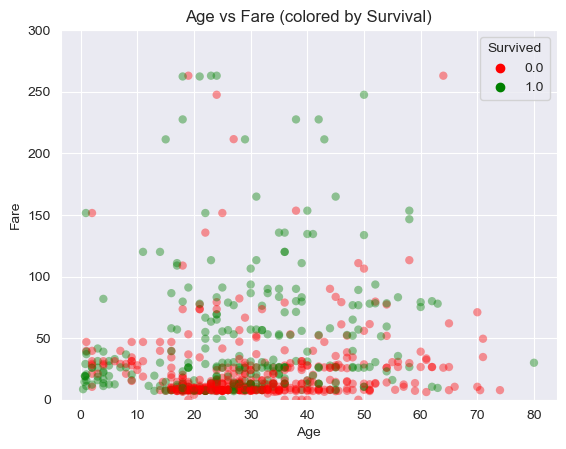

In [36]:
# Multivariate Age vs Fare by survival.

sns.scatterplot(data=df, x='Age', y='Fare',hue='Survived',
                palette={0: 'red', 1: 'green'}, alpha=0.4, edgecolor='none' )
plt.title('Age vs Fare (colored by Survival)')
plt.ylim(0, 300)
plt.show()

### Observations:- 

- We can clearly observe that the people those who had purchased the higher price ticket were survived the most. Also the more passenger died those who purchased the least price tickets.

Parch
3    60.000000
1    55.084746
2    50.000000
0    34.365782
5    20.000000
4     0.000000
6     0.000000
9          NaN
Name: Survived, dtype: float64


Text(0.5, 1.0, 'Survival with Parent and Child')

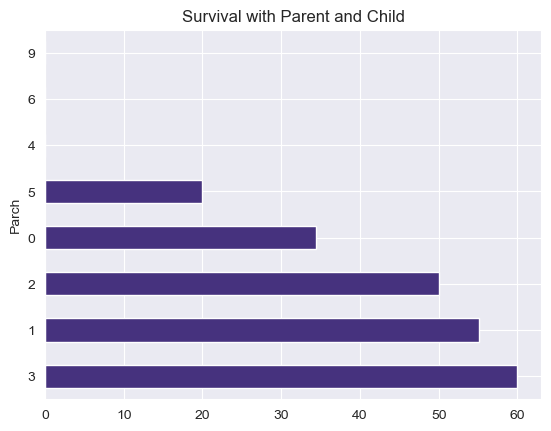

In [37]:
# Average survival of Parch

grp = df.groupby('Parch')['Survived'].mean().sort_values(ascending = False)*100
grp.plot(kind='barh')
print(grp)
plt.title("Survival with Parent and Child")

In [38]:
df.groupby('Parch').agg(
    Total_Passengers = ('Survived', 'count'),
    Total_Survived   = ('Survived', 'sum'),
    Survival_Pct     = ('Survived', lambda x: round(x.mean()*100, 1))
).sort_values(by='Survival_Pct',ascending=False)

,Total_Passengers,Total_Survived,Survival_Pct
Parch,,,
3,5,3.0,60.0
1,118,65.0,55.1
2,80,40.0,50.0
0,678,233.0,34.4
5,5,1.0,20.0
4,4,0.0,0.0
6,1,0.0,0.0
9,0,0.0,NaN


### Observation:- 
- From the above observation we can state that the small family i.e. 1 parent 2 child or 2 child (consiting of total 3 members) has survived the most.

# Comparing all at one place.

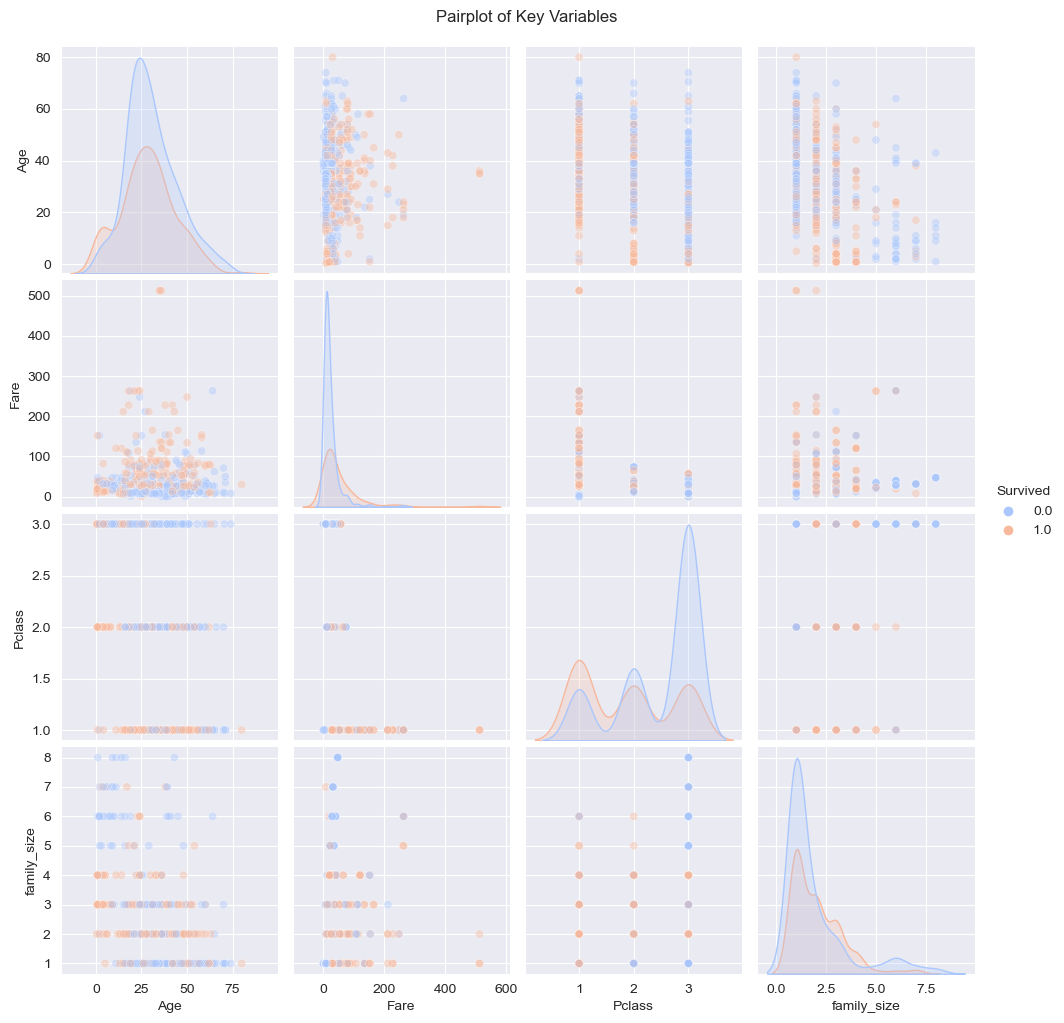

In [39]:
# We have compared every bivariate analysis at one place.

sns.pairplot(df[['Survived', 'Age', 'Fare', 'Pclass', 'family_size']].dropna(),
             hue='Survived', plot_kws={'alpha': 0.4}, palette='coolwarm',
             diag_kind='kde')
plt.suptitle('Pairplot of Key Variables', y=1.02)
plt.show()

# -----------------------------------------------------------------

# Multi-Variate Analysis.

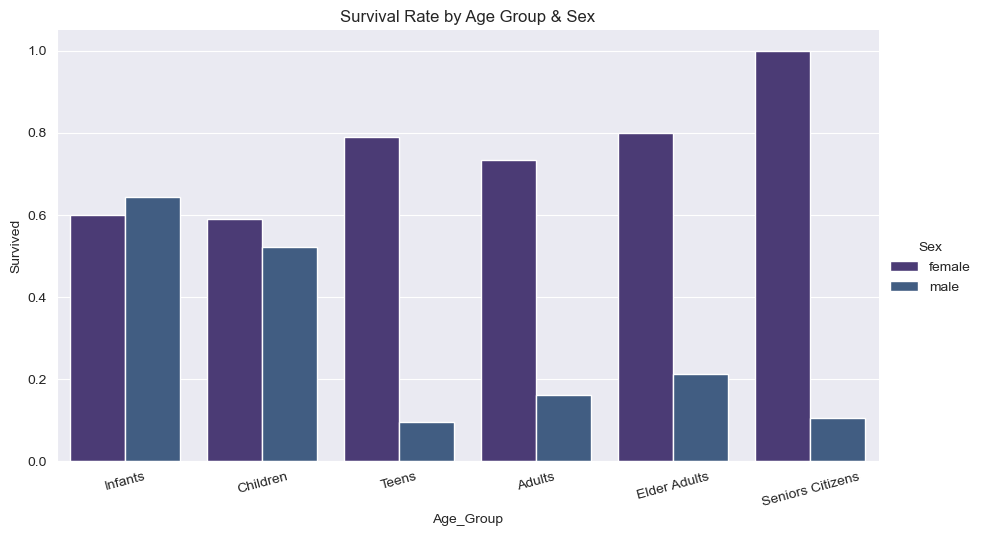

In [40]:
# Survival rate of AgeGroup according to Sex.

sns.catplot(data=df, x='Age_Group', y='Survived', hue='Sex',
            kind='bar', height=5, aspect=1.8, ci=False,
            order=['Infants','Children','Teens','Adults','Elder Adults','Seniors Citizens'])
plt.title('Survival Rate by Age Group & Sex')
plt.xticks(rotation=15)
plt.show()

### Observation:- 
- Only Infants and Children are categories where the males and females are saved the most

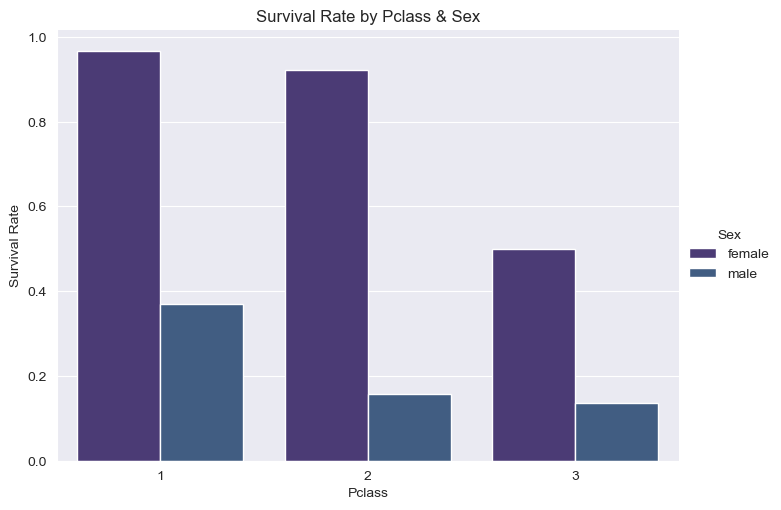

In [41]:
# Survival Rate By Sex and Pclass

sns.catplot(data=df, x='Pclass', y='Survived', hue='Sex', kind='bar', height=5, aspect=1.4, ci=False)
plt.title('Survival Rate by Pclass & Sex')
plt.ylabel('Survival Rate')
plt.show()

### Observation:- 
- When we analysed the Survival and Pclass along with Sex we get to know that in all the 3 classes Females were saved like more than 50%.

Text(0.5, 1.0, 'Survival of Sex and Embarked.')

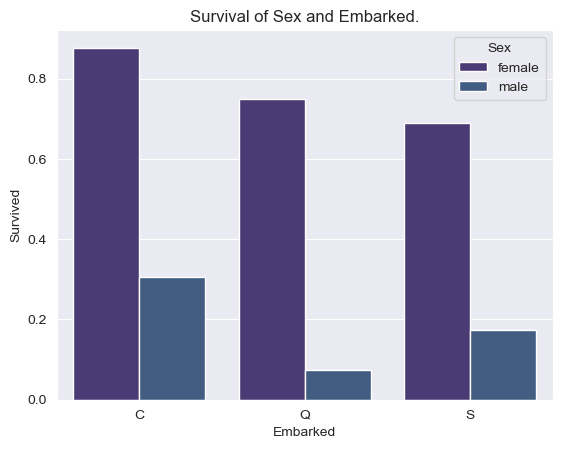

In [42]:
sns.barplot(data=df, x='Embarked',y='Survived',hue='Sex',ci=False)
plt.title("Survival of Sex and Embarked.")

### Observation:- 
- Also in Embarked mostly Females were saved.

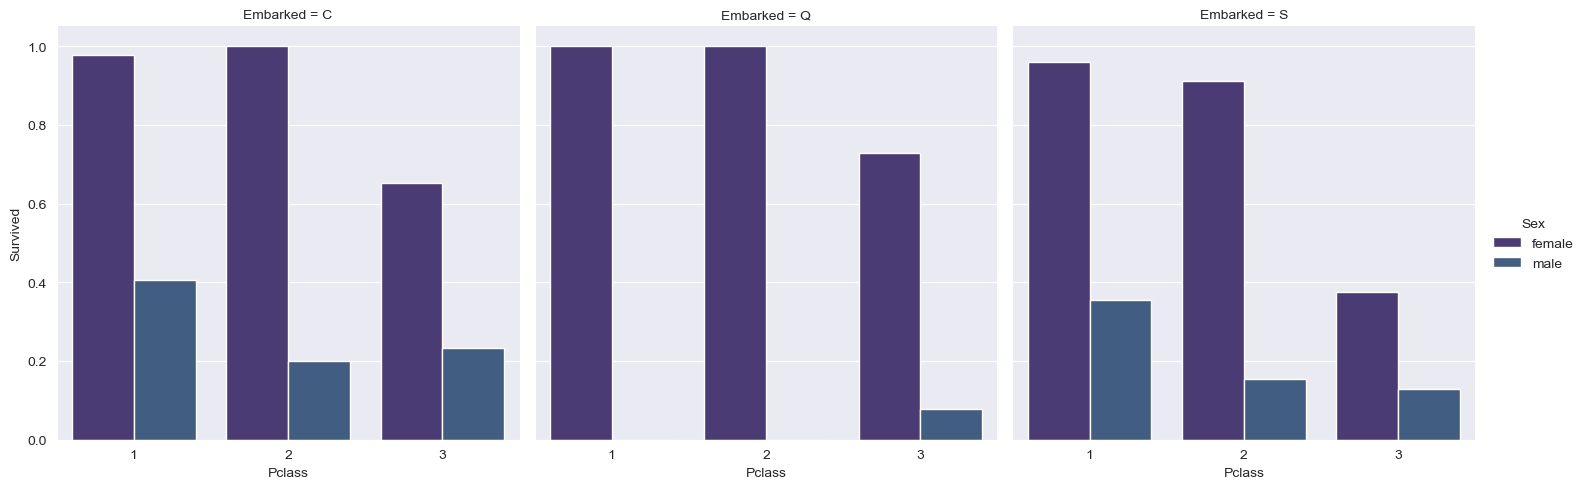

In [43]:
sns.catplot(data=df, x='Pclass',y='Survived', hue='Sex',col='Embarked',
            kind='bar',ci=False )

Pclass and Survived count:- Pclass
1    216
2    184
3    491
Name: Survived, dtype: int64
---------------------------------------------
Pclass and Survived Average:- Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


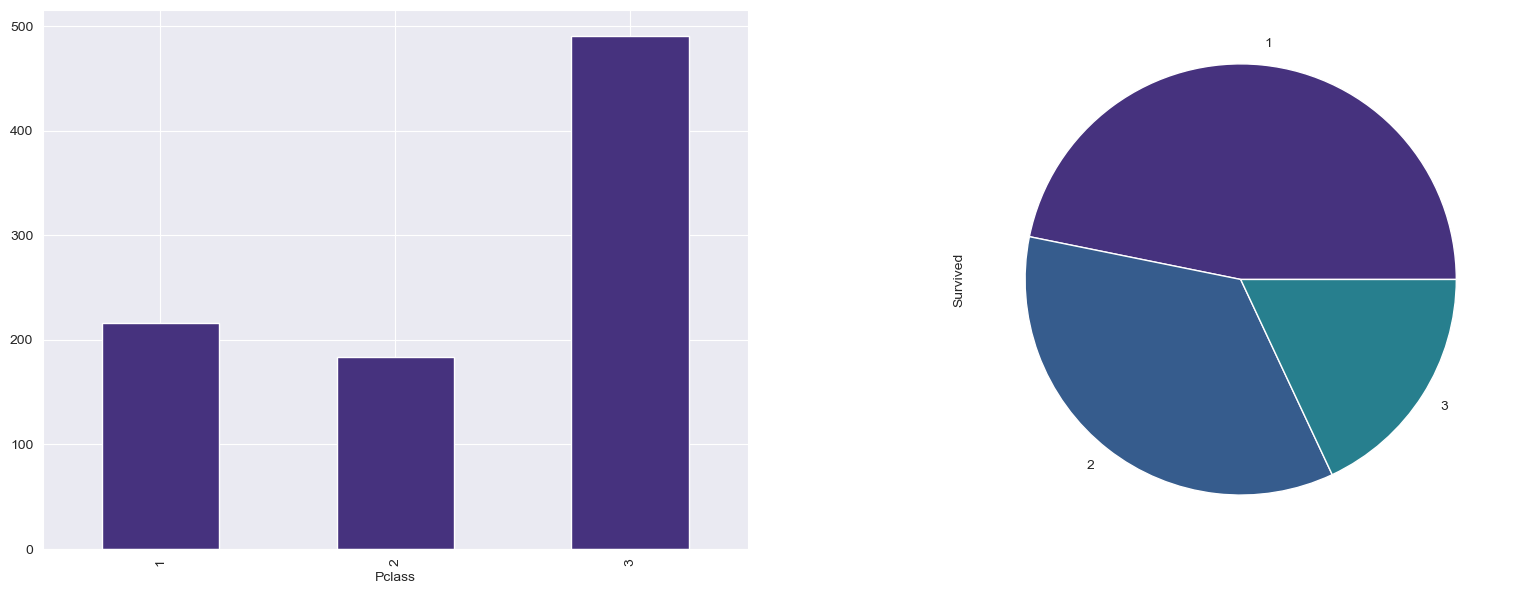

In [44]:
# Analysis of Pclass and Their Survival Rate in %.
fig,ax = plt.subplots(1,2,figsize = (20,7))

class_sur = df.groupby("Pclass")['Survived'].mean()*100
class_sur_cnt = df.groupby("Pclass")['Survived'].count()

class_sur_cnt.plot(kind='bar',ax=ax[0])
class_sur.plot(kind="pie",ax=ax[1])

print(f"Pclass and Survived count:- {class_sur_cnt}")
print("-"*45)
print(f"Pclass and Survived Average:- {class_sur}")

**Observations from above charts:-**
- According to the data around **216** i.e. **62.96 %** of average passengers has survived in Pclass 1. In Pclass 2 **184** i.e. **47.28%** and in Pclass 3 **419** i.e. **24.23%** 

Embarked and Survived count:- Embarked
C    168
Q     77
S    644
Name: Survived, dtype: int64
---------------------------------------------
Embarked and Survived Average:- Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64


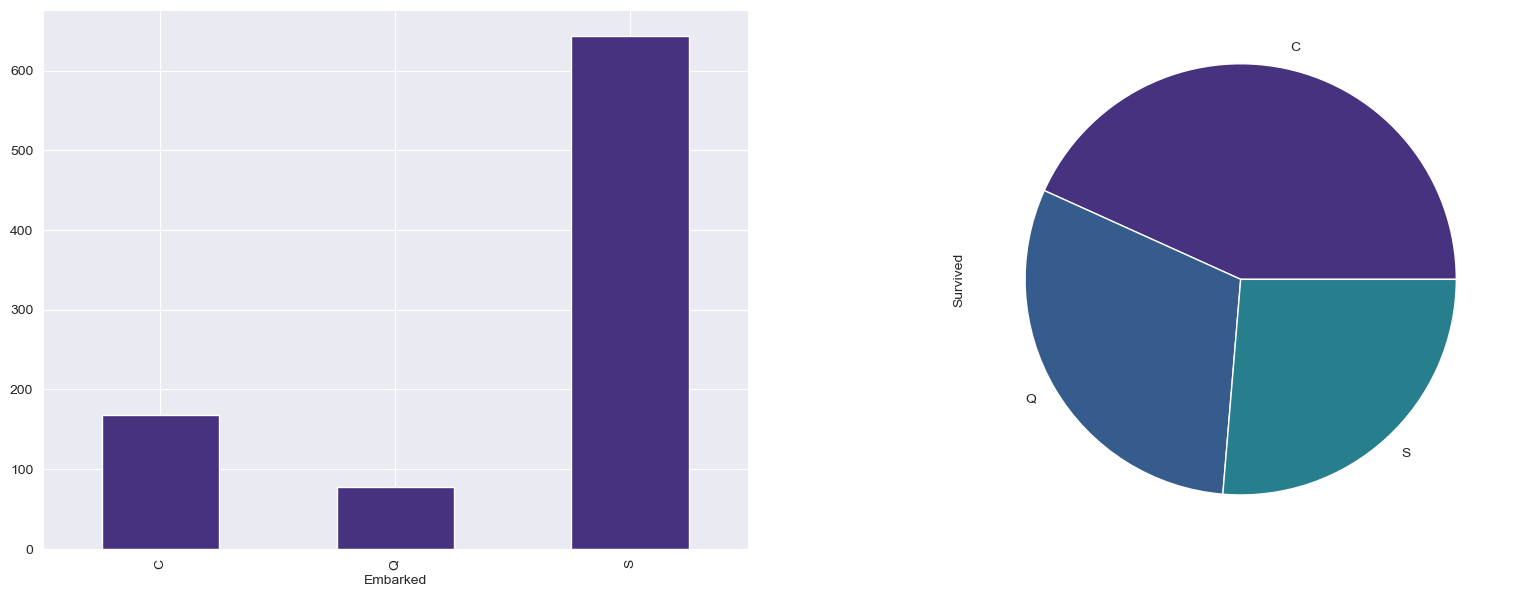

In [45]:
# Analysis on Embarked
fig,ax = plt.subplots(1,2,figsize = (20,7))

Emb_sur_cnt = df.groupby("Embarked")['Survived'].count()
Emb_sur = df.groupby("Embarked")['Survived'].mean()*100

Emb_sur_cnt.plot(kind='bar',ax=ax[0])
Emb_sur.plot(kind="pie",ax=ax[1])

print(f"Embarked and Survived count:- {Emb_sur_cnt}")
print("-"*45)
print(f"Embarked and Survived Average:- {Emb_sur}")

**Observations on Embarked:-**
- We noticed that the most numbers of passengers were survived on C(Cherbourg) i.e. 55.35% but having only 168 passengers.
- In Q(Queenstown) 38.96 % passengers survived having only 77 Passengers on board.
- In S(Southampton) 33.69% Passengers survived having total of 644 Passengers.